In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
image = cv2.imread("/mnt/e/Image processing and computer vision using OpenCV/class.vision-master/images/approx.jpg")
print(f"Shape of image: {image.shape}")

Shape of image: (148, 207, 3)


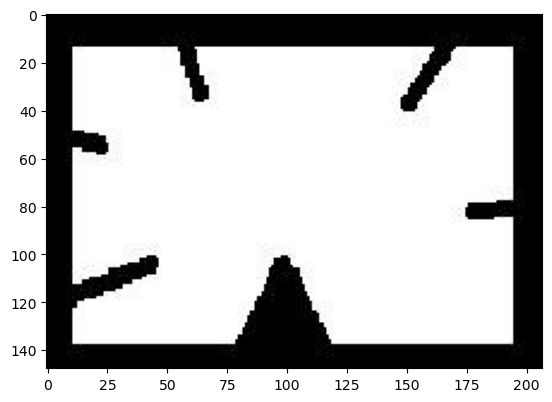

In [3]:
plt.imshow(image[..., ::-1])

In [4]:
ret, thresh = cv2.threshold(image, 1, 255, cv2.THRESH_BINARY)
print(f"shape of threshold image: {thresh.shape}")

shape of threshold image: (148, 207, 3)


In [5]:
binary_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print(f"Shape of binary image: {binary_image.shape}")

Shape of binary image: (148, 207)


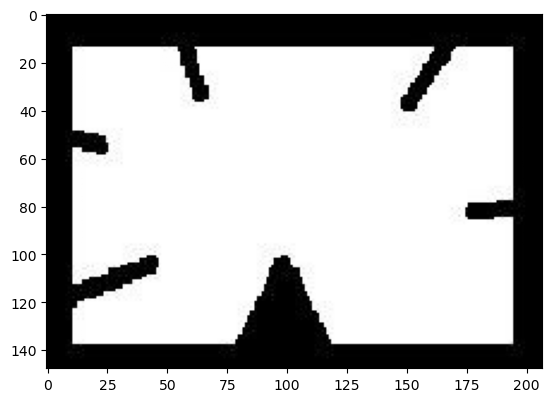

In [6]:
plt.imshow(binary_image, cmap='gray')

In [7]:
contours, _ = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
print(f"Number of contours: {len(contours)}")   

Number of contours: 349


In [8]:
open_binary = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, kernel=np.ones(shape=(5, 5)))

In [9]:
contours, _ = cv2.findContours(open_binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
print(f"Number of contours: {len(contours)}")   

Number of contours: 1


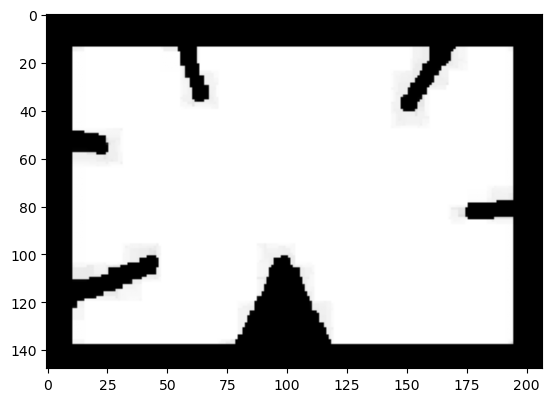

In [10]:
plt.imshow(open_binary, cmap='gray')

In [ ]:
epsilon_1 = 0.1 * cv2.arcLength(contours[0], True)  # Error of approximation
epsilon_2 = 0.01 * cv2.arcLength(contours[0], True)

approx_1 = cv2.approxPolyDP(contours[0], epsilon_1, True)
approx_2 = cv2.approxPolyDP(contours[0], epsilon_2, True)

print(f"Shape of original countour: {contours[0].shape}")
print(f"Shape of approximated contour with epsilon: 0.1: {approx_1.shape}")
print(f"Shape of approximated contour with epsilon: 0.01: {approx_2.shape}")

Shape of original countour: (895, 1, 2)
Shape of approximated contour with epsilon: 0.1: (4, 1, 2)
Shape of approximated contour with epsilon: 0.01: (22, 1, 2)


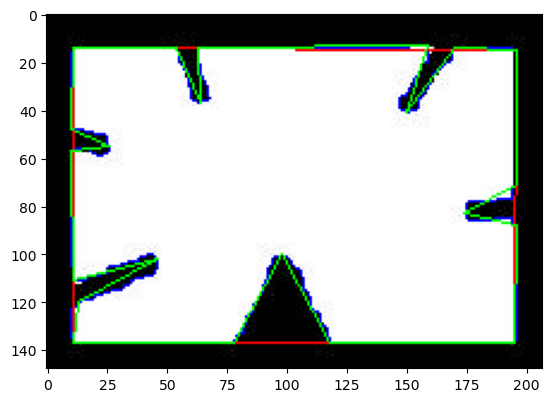

In [12]:
cv2.drawContours(image, contours, 0, (255, 0, 0), 1)
cv2.drawContours(image, [approx_1], 0, (0, 0, 255), 1)
cv2.drawContours(image, [approx_2], 0, (0, 255, 0), 1)

plt.imshow(image[..., ::-1])

___

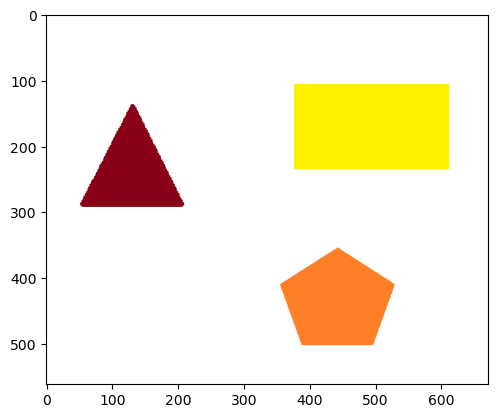

In [2]:
image = cv2.imread("/mnt/e/Image processing and computer vision using OpenCV/class.vision-master/images/shapes2.png", cv2.IMREAD_COLOR_BGR)
plt.imshow(image[..., ::-1])

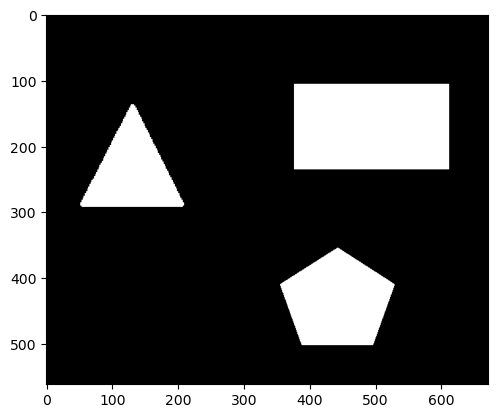

In [3]:
binary_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(binary_image, 240, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh, cmap='gray')

In [4]:
import cv2

contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

for contour in contours:
    epsilon = 0.02 * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)

    x = approx.ravel()[0]
    y = approx.ravel()[1]

    if len(approx) == 3:
        shape = "Triangle"

    elif len(approx) == 4:
        _, _, w, h = cv2.boundingRect(approx)
        if 0.95 <= w / float(h) <= 1.05:
            shape = "Square"
        else:
            shape = "Rectangle"

    elif len(approx) == 5:
        shape = "Pentagon"

    elif len(approx) == 6:
        shape = "Hexagon"

    else:
        shape = "Circle"

    cv2.drawContours(image, [approx], -1, (0, 255, 0), 2)
    cv2.putText(
        image,
        shape,
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

cv2.imshow("Shapes", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/mohammadjavad/anaconda3/envs/gnn_env/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/mohammadjavad/anaconda3/envs/gnn_env/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/mohammadjavad/anaconda3/envs/gnn_env/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/mohammadjavad/anaconda3/envs/gnn_env/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to font